# Netherlands - the whole country, 2011-2015

T-Mobile NL's commercial microwave links over the Netherlands: 15-minute minimum and
maximum received power (`Pmin`, `Pmax`) of on average ~3070 sub-links on ~1818 paths,
13 January 2011 to 15 March 2015 with gaps. Overeem, Walraven, Leijnse and Uijlenhoet
(2024), [doi:10.4121/be252844-b672-471e-8d69-27269a862ec1.v1](https://doi.org/10.4121/be252844-b672-471e-8d69-27269a862ec1.v1),
CC BY 4.0. It is not one of the OpenSense example subsets: the archive is a single
9.5 GB zip, read here through `core.opensense.netherlands`.

| | |
|---|---|
| signal | `Pmin`/`Pmax` over each 15 min (dBm); Nokia 1 dB, NEC 0.1 dB resolution; no transmitted power (constant) |
| time | the **end** of the 15-min interval, UTC |
| links | `cml_id` = a path, named by its endpoints; `sublink_0/1` = its two directions (RAINLINK IDs kept as `rainlink_id`) |
| polarization | not given; mostly vertical according to the operator |

```bash
python -m core.opensense.fetch --dataset netherlands    # once: the zip, into ~/data/cml/netherlands/_download/
```

`open_months` converts the months it needs to `~/data/cml/netherlands/monthly/` on first
use (~3 min a month: the zip is streamed, never unpacked).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from core import viz_style as vs
from core.geo import haversine_m
from core.opensense import netherlands as nl
from core.opensense.conventions import check_format

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)
LABEL = {"NOKIA": "Nokia", "NEC": "NEC"}

## One week of July 2012

The month files hold `rsl_min` and `rsl_max(cml_id, sublink_id, time)`; a week of the
whole network is ~70 MB in memory.

In [2]:
ds = nl.open_months("2012-07-08", "2012-07-15")
ds

<xarray.Dataset> Size: 30MB
Dimensions:      (cml_id: 2728, sublink_id: 2, time: 672)
Coordinates:
  * cml_id       (cml_id) <U33 360kB '50.76375_6.01829_50.77708_6.01596' ... ...
  * sublink_id   (sublink_id) <U9 72B 'sublink_0' 'sublink_1'
  * time         (time) datetime64[ns] 5kB 2012-07-08T00:15:00 ... 2012-07-15
    site_0_lat   (cml_id) float64 22kB 50.76 50.76 50.77 ... 53.4 53.41 53.45
    site_0_lon   (cml_id) float64 22kB 6.018 6.018 5.862 ... 5.349 6.725 5.637
    site_1_lat   (cml_id) float64 22kB 50.78 50.85 50.82 ... 53.45 53.45 53.45
    site_1_lon   (cml_id) float64 22kB 6.016 6.005 5.833 ... 5.637 6.808 5.791
    length       (cml_id) float64 22kB 1.491 9.723 6.404 ... 19.69 6.884 10.25
    vendor       (cml_id) <U5 55kB 'NOKIA' 'NEC' 'NEC' ... 'NEC' 'NOKIA' 'NEC'
    frequency    (cml_id, sublink_id) float64 44kB 39.17 37.91 ... 19.09 18.09
    rainlink_id  (cml_id, sublink_id) int64 44kB 2177 2229 1488 ... -1 2052 2049
    direction    (cml_id, sublink_id) int8 5kB 0 1 0 1 0 1 0 ... -1 0 1 1 -1 0 1
Data variables:
    rsl_min      (cml_id, sublink_id, time) float32 15MB -51.0 -51.0 ... -49.7
    rsl_max      (cml_id, sublink_id, time) float32 15MB -51.0 -51.0 ... -48.7
Attributes:
    title:         Netherlands CML (Overeem et al. 2024), RAINLINK min/max fo...
    source:        doi:10.4121/be252844-b672-471e-8d69-27269a862ec1.v1
    license:       CC-BY-4.0
    polarization:  not given (mostly vertical)
    time_label:    end of 15-min interval

It passes the OpenSense CML format checks once `rsl_min` stands in for `rsl` (there is
no single received level, only the minimum and maximum over 15 minutes).

In [3]:
check_format(ds.rename(rsl_min="rsl"))

,check,passed,detail
0,"dimensions time, cml_id, sublink_id",True,
1,time is datetime64,True,datetime64[ns]
2,cml_id is a string,True,<U33
3,sublink_id is a string,True,<U9
4,"site coordinates, frequency, length",True,
5,rsl present (tsl optional),True,found ['rsl']
6,rsl in dBm,True,units='dBm'
7,frequency units declared,True,units='GHz'
8,length units declared,True,units='km'


2728 paths, 4737 sub-links (2948 Nokia, 1789 NEC)
frequency 7.5 .. 58.2 GHz, median 38.0; 0 sub-links at >= 60 GHz
length    0.00 .. 27.9 km, median 2.67; 2 of 0 km
usable (0 < L, f < 60 GHz): 4735 sub-links


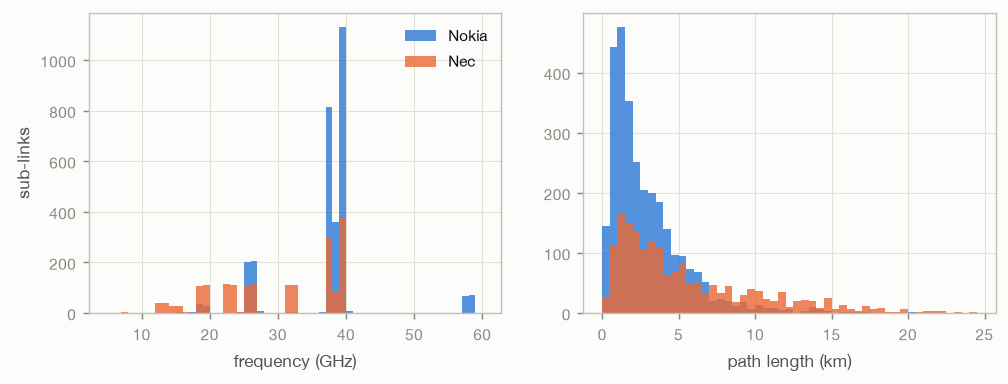

In [4]:
sub = nl.sublinks(ds)
f, L = sub.frequency.values, sub.length.values
print(f"{ds.sizes['cml_id']} paths, {sub.sizes['cml_id']} sub-links "
      f"({(sub.vendor == 'NOKIA').sum().item()} Nokia, {(sub.vendor == 'NEC').sum().item()} NEC)")
print(f"frequency {np.nanmin(f):.1f} .. {np.nanmax(f):.1f} GHz, median {np.nanmedian(f):.1f}; "
      f"{(f >= 60).sum()} sub-links at >= 60 GHz")
print(f"length    {np.nanmin(L):.2f} .. {np.nanmax(L):.1f} km, median {np.nanmedian(L):.2f}; "
      f"{(L == 0).sum()} of 0 km")
print(f"usable (0 < L, f < 60 GHz): {nl.usable(sub).sizes['cml_id']} sub-links")

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
ok = f < 60
for v, c in (("NOKIA", C1), ("NEC", C2)):
    sel = (sub.vendor.values == v) & ok
    axes[0].hist(f[sel], bins=np.arange(5, 61, 1), color=c, alpha=0.8, label=v.title())
    axes[1].hist(L[sel], bins=np.arange(0, 25, 0.5), color=c, alpha=0.8, label=v.title())
axes[0].set(xlabel="frequency (GHz)", ylabel="sub-links")
axes[1].set(xlabel="path length (km)")
axes[0].legend();

The README of the dataset drops the same sub-links before its figures: a few with
identical endpoints (0 km) and some reporting 254.135 GHz. `nl.usable` does the same.

## The network, and KNMI's automatic gauges

KNMI's hourly precipitation (`RH`, 0.1 mm) from the open climatology service, with the
station list it sends along; stations without a rain sensor are dropped.

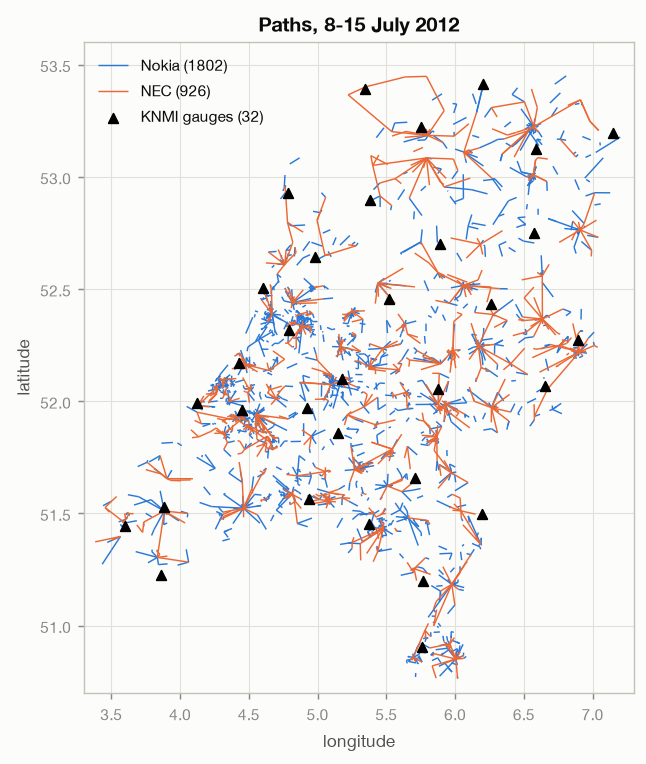

In [5]:
gauges = nl.knmi_hourly("2012-07-08", "2012-07-15")
paths = ds                                  # the path form: one row per path
fig, ax = plt.subplots(figsize=(6, 6.5))
for v, c in (("NOKIA", C1), ("NEC", C2)):
    sel = paths.vendor.values == v
    segs = np.stack([np.c_[paths.site_0_lon.values[sel], paths.site_0_lat.values[sel]],
                     np.c_[paths.site_1_lon.values[sel], paths.site_1_lat.values[sel]]], axis=1)
    ax.add_collection(LineCollection(segs, colors=c, linewidths=0.8, label=f"{LABEL[v]} ({sel.sum()})"))
ax.scatter(gauges.lon, gauges.lat, marker="^", c="k", s=28, zorder=3,
           label=f"KNMI gauges ({gauges.sizes['station']})")
ax.set(xlim=(3.3, 7.3), ylim=(50.7, 53.6), xlabel="longitude", ylabel="latitude",
       title="Paths, 8-15 July 2012")
ax.set_aspect(1 / np.cos(np.radians(52.2)))
ax.legend(loc="upper left");

## One link, and the gauge next to it

The path whose midpoint is nearest a gauge, among those with a complete week, on the
gauge's wettest day. `Pmin` drops further than `Pmax` in rain: the rain is not steady
within 15 minutes. RAINLINK turns each into a rain rate and weights them, 0.33 on the
one from `Pmin` (the largest attenuation) and 0.67 on the one from `Pmax`.

gauge 249 Berkhout; wettest day 2012-07-14 (40.4 mm)
link 52.63572_5.01129_52.64995_5.05378/sublink_0: 3.27 km, 39.4 GHz, NOKIA, midpoint 3.6 km from the gauge


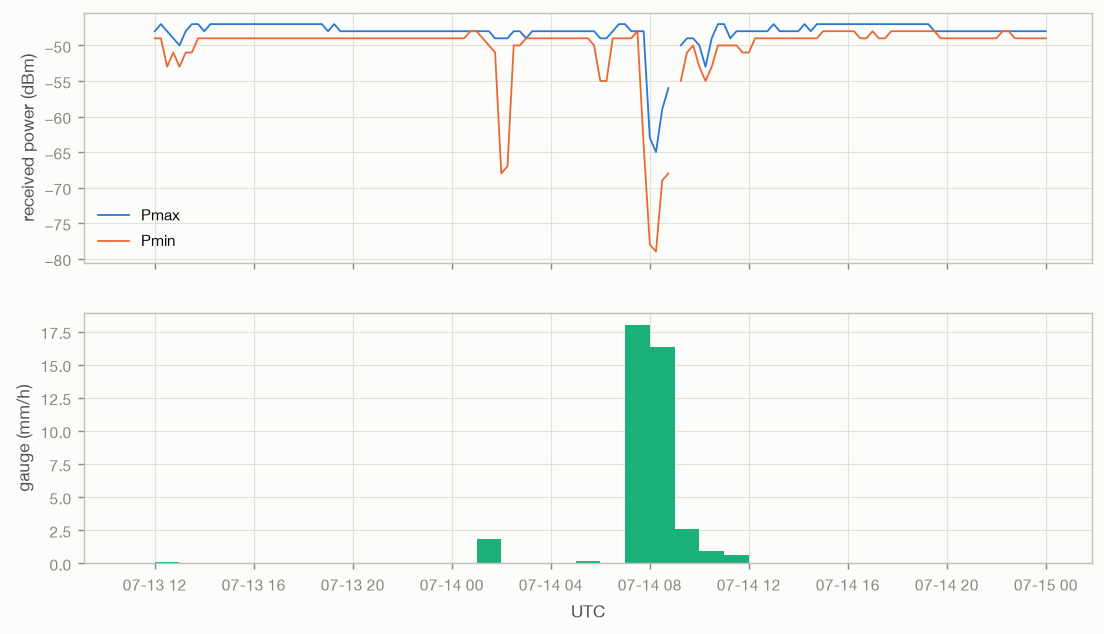

In [6]:
day_tot = gauges.resample(time="1D", closed="right", label="left").sum()
st = int(day_tot.max("time").idxmax("station"))
day = pd.Timestamp(day_tot.sel(station=st).idxmax("time").item())
g = gauges.sel(station=st)
usable = ((sub.length > 0) & (sub.frequency < 60)).values
complete = (sub.pmin.notnull().mean("time") > 0.95).values & usable
d = haversine_m(sub.mid_lat.values, sub.mid_lon.values, float(g.lat), float(g.lon)) / 1000
k = int(np.where(complete, d, np.inf).argmin())
link = sub.isel(cml_id=k)
print(f"gauge {st} {str(g.station_name.item())}; wettest day {day.date()} ({float(day_tot.sel(station=st, time=day)):.1f} mm)")
print(f"link {link.cml_id.item()}: {float(link.length):.2f} km, {float(link.frequency):.1f} GHz, "
      f"{link.vendor.item()}, midpoint {d[k]:.1f} km from the gauge")

w = slice(day - pd.Timedelta("12h"), day + pd.Timedelta("36h"))
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(link.time.sel(time=w), link.pmax.sel(time=w), color=C1, lw=1, label="Pmax")
axes[0].plot(link.time.sel(time=w), link.pmin.sel(time=w), color=C2, lw=1, label="Pmin")
axes[0].set(ylabel="received power (dBm)")
axes[0].legend()
gw = g.sel(time=w)
axes[1].bar(gw.time.values - pd.Timedelta("30min"), gw.values, width=1 / 24, color=C3, align="center")
axes[1].set(ylabel="gauge (mm/h)", xlabel="UTC");

Retrieving rain from these levels (RAINLINK's nearby-link wet/dry classification,
reference level, wet-antenna correction and the Pmin/Pmax weighting) and mapping it over
the country is the subject of [`projects/maps/netherlands`](../projects/maps/netherlands/).